In [146]:
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import gensim
import gensim.corpora as corpora
from gensim.models import LdaModel, CoherenceModel
from wordcloud import WordCloud

BASE_DIR  = Path.cwd().parent   # notebooks run from notebooks/ subfolder
RAW       = BASE_DIR / "data" / "raw"
PROCESSED = BASE_DIR / "data" / "processed"
OUTPUTS   = BASE_DIR / "outputs"
MODELS    = BASE_DIR / "models"

# Load preprocessed data (has tokens, audio features, days_in_top50)
df = pd.read_csv(PROCESSED / "lyrics_preprocessed.csv")

# tokens column is stored as a stringified list in CSV — parse it back
df["tokens"] = df["tokens"].apply(ast.literal_eval)

df.head(2)

,spotify_id,name,artists,album_name,album_release_date,danceability,energy,valence,tempo,loudness,...,entry_date,exit_date,days_in_top50,lyrics,language,lyrics_length,lyrics_clean,word_count,lyrics_preproc_v2,tokens
0,4KULAymBBJcPRpk1yO4dOG,I Remember Everything (feat. Kacey Musgraves),"Zach Bryan, Kacey Musgraves",Zach Bryan,2023-08-25,0.429,0.453,0.155,77.639,-7.746,...,2023-10-18,2025-06-11,603,[Verse 1: Zach Bryan]\nRotgut whiskey's gonna ...,en,1886,rotgut whiskey s gonna ease my mind beach towe...,172,rotgut whiskey gon ease mind beach towel rest ...,"[rotgut, whiskey, gon, ease, mind, beach, towe..."
1,7KA4W4McWYRpgf0fWsJZWB,See You Again (feat. Kali Uchis),"Tyler, The Creator, Kali Uchis",Flower Boy,2017-07-21,0.558,0.559,0.620,78.558,-9.222,...,2023-10-18,2025-06-11,603,"[Intro: Tyler, The Creator]\nOkay, okay, okay,...",en,2665,okay okay okay okay okay okay o you live in my...,268,okay okay okay okay okay okay live dream state...,"[okay, okay, okay, okay, okay, okay, live, dre..."


In [147]:
# Set to True to re-run LDA even if output already exists
FORCE_RECOMPUTE = False

## Topic Modeling with Gensim LDA

We use Gensim's implementation of Latent Dirichlet Allocation (LDA) to identify common lyrical themes in the dataset. We'll build a Dictionary and Bag-of-Words corpus from our clean tokens.

In [148]:
# Step 1 — Build the Gensim Dictionary and Corpus
# We use the already tokenized lists in the 'tokens' column.

data_words = df['tokens'].tolist()

# Create Dictionary
id2word = corpora.Dictionary(data_words)

# Filter out tokens that appear in less than 5 documents or more than 85% of the documents.
# Also keep only the top 3000 most frequent tokens.
id2word.filter_extremes(no_below=5, no_above=0.85, keep_n=3000)

# Create Bag-of-Words Corpus: Term Document Frequency
corpus = [id2word.doc2bow(text) for text in data_words]

print(f"Number of unique tokens in Dictionary: {len(id2word)}")
print(f"Number of documents in Corpus: {len(corpus)}")

Number of unique tokens in Dictionary: 2369
Number of documents in Corpus: 682


In [149]:
# Step 2 — Evaluate Number of Topics (k) - Coherence Score
# (Optional block, comment out to skip slow search)
"""
coherence_scores = []
ks = range(4, 12)
for k in ks:
    model = LdaModel(corpus=corpus, id2word=id2word, num_topics=k, random_state=42, passes=10)
    coherencemodel = CoherenceModel(model=model, texts=data_words, dictionary=id2word, coherence='c_v')
    coherence_scores.append(coherencemodel.get_coherence())

plt.plot(list(ks), coherence_scores, marker='o')
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score (higher = better)")
plt.title("LDA Coherence by Number of Topics")
plt.show()
"""

'\ncoherence_scores = []\nks = range(4, 12)\nfor k in ks:\n    model = LdaModel(corpus=corpus, id2word=id2word, num_topics=k, random_state=42, passes=10)\n    coherencemodel = CoherenceModel(model=model, texts=data_words, dictionary=id2word, coherence=\'c_v\')\n    coherence_scores.append(coherencemodel.get_coherence())\n\nplt.plot(list(ks), coherence_scores, marker=\'o\')\nplt.xlabel("Number of Topics")\nplt.ylabel("Coherence Score (higher = better)")\nplt.title("LDA Coherence by Number of Topics")\nplt.show()\n'

 Based on expected themes (e.g., love, street, party, sadness, etc.) we fit the LDA model with $K=7$ topics.

In [ ]:
# Step 3 — Fit the Gensim LDA model
K = 3

lda_final = LdaModel(
    corpus=corpus,
    id2word=id2word,
    num_topics=K,
    random_state=42,
    update_every=1,
    chunksize=100,
    passes=20,
    alpha='auto',
    per_word_topics=True
)

### Extractive Topic Summarization
Instead of "Topic 0", we will automatically grab the top 3 heavily weighted words for each topic separated by a pipe `|` and use that as the column name.

In [151]:
# Step 4 — Inspect Topics and Generate 3-4 word Extractive Labels
topic_labels = {}

for t in range(K):
    # Get top 3 words
    top_words = [word for word, weight in lda_final.show_topic(t, topn=3)]
    label = " | ".join(top_words)
    topic_labels[t] = label
    
    # Print the top 10 words for detailed checking
    top_10 = [word for word, weight in lda_final.show_topic(t, topn=10)]
    print(f"Topic {t} [{label}]: {', '.join(top_10)}")

Topic 0 [love | baby | girl]: love, baby, girl, dance, know, tell, want, make, please, right
Topic 1 [nigga | bitch | shit]: nigga, bitch, shit, get, fuck, em, go, one, let, know
Topic 2 [know | let | life]: know, let, life, love, one, go, baby, back, say, way
Topic 3 [would | know | cause]: would, know, cause, time, keep, wish, never, come, man, away


Now we generate WordClouds for each discovered topic to visualize what vocabulary separates them.

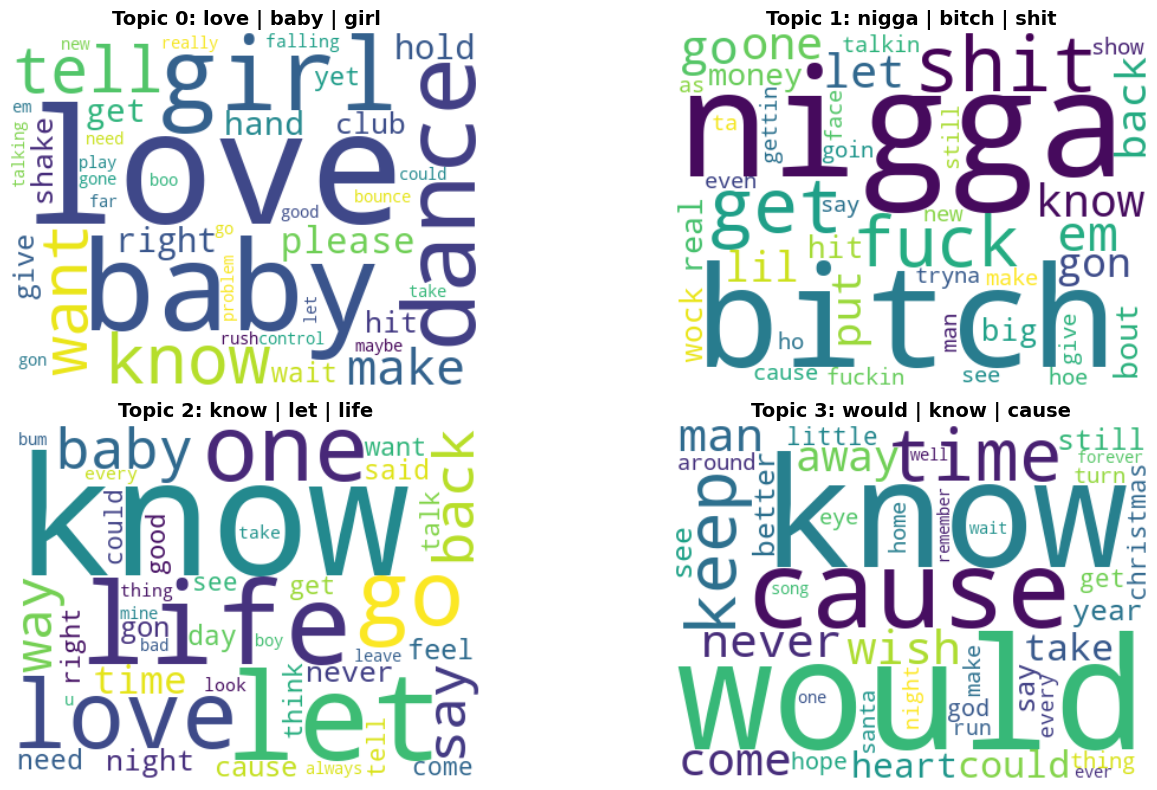

In [152]:
# Step 5 — WordCloud Visualization per Topic
fig, axes = plt.subplots(int(np.ceil(K/2)), 2, figsize=(15, 4 * np.ceil(K/2)), sharex=True, sharey=True)
axes = axes.flatten()

for t in range(K):
    ax = axes[t]
    # Fetch topic word distribution as dictionary specifically for wordcloud
    word_freq = dict(lda_final.show_topic(t, topn=40))
    
    wc = WordCloud(background_color='white', width=400, height=300, colormap='viridis', max_words=40)
    wc.generate_from_frequencies(word_freq)
    
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f"Topic {t}: {topic_labels[t]}", fontdict={'fontsize': 14, 'fontweight': 'bold'})
    ax.axis('off')

# Turn off any unused axes if K is odd
for i in range(K, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Now we extract the newly labeled topic distributions as features for each song, finding the dominant topic.

In [153]:
# Step 6 — Extract Per-Song Topic Distributions
def get_document_topics(bow):
    # Gensim returns a list of (topic_id, probability) tuples
    topic_probs = lda_final.get_document_topics(bow, minimum_probability=0.0)
    # Convert to a flat list ordered by topic index 0 to K-1
    return [prob for topic_id, prob in sorted(topic_probs, key=lambda x: x[0])]

topic_dist = np.array([get_document_topics(bow) for bow in corpus])

# Create column names using our extractive labels
topic_cols = [topic_labels[i] for i in range(K)]
topic_df = pd.DataFrame(topic_dist, columns=topic_cols, index=df.index)

# Drop existing topic columns if we are re-running to avoid duplicates
cols_to_drop = [c for c in df.columns if '|' in c or c in ["dominant_topic", "topic_confidence"]]
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)

# Add topic distributions to main dataframe
df = pd.concat([df, topic_df], axis=1)

# Extract Dominant Topic Label
dominant_idx = topic_dist.argmax(axis=1)
df["dominant_topic"] = [topic_labels[i] for i in dominant_idx]
df["topic_confidence"] = topic_dist.max(axis=1)

df[["lyrics_preproc_v2", "dominant_topic", "topic_confidence"]].head()

,lyrics_preproc_v2,dominant_topic,topic_confidence
0,rotgut whiskey gon ease mind beach towel rest ...,would | know | cause,0.681070
1,okay okay okay okay okay okay live dream state...,know | let | life,0.995146
2,something hold lately know anymore feel wall c...,know | let | life,0.500069
3,think know touch fire three four time testify ...,know | let | life,0.454084
4,still fan even though salty hate see broad kno...,know | let | life,0.571951


### Visualizing Labeled Dominant Topics and Chart Persistence

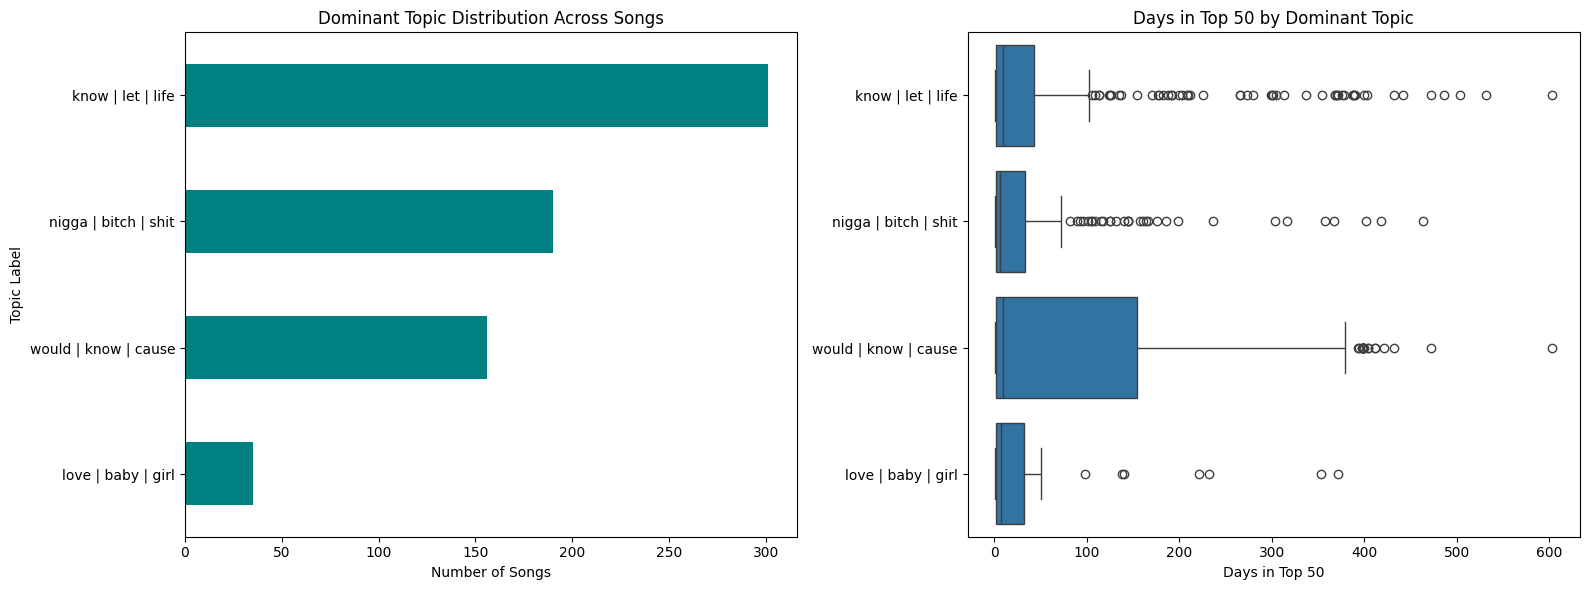

In [154]:
# Step 7 — Visualize with Descriptive Labels
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# a) Topic distribution across the corpus
feature_counts = df["dominant_topic"].value_counts()
feature_counts.plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title("Dominant Topic Distribution Across Songs")
axes[0].set_xlabel("Number of Songs")
axes[0].set_ylabel("Topic Label")
axes[0].invert_yaxis() # Display largest category at the top

# b) Topic vs. days_in_top50 (boxplot)
sns.boxplot(y="dominant_topic", x="days_in_top50", data=df, ax=axes[1], order=feature_counts.index)
axes[1].set_title("Days in Top 50 by Dominant Topic")
axes[1].set_xlabel("Days in Top 50")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Top 5 Songs per Labeled Topic
Which songs have the highest confidence score for each specific topic?

/var/folders/jc/7lltm7w5571fpqx3p4sch2gh0000gn/T/ipykernel_26405/1332065183.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_songs[label], y=song_names, ax=ax, palette="viridis")
/var/folders/jc/7lltm7w5571fpqx3p4sch2gh0000gn/T/ipykernel_26405/1332065183.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_songs[label], y=song_names, ax=ax, palette="viridis")
/var/folders/jc/7lltm7w5571fpqx3p4sch2gh0000gn/T/ipykernel_26405/1332065183.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_songs[label], y=song_names, ax=ax,

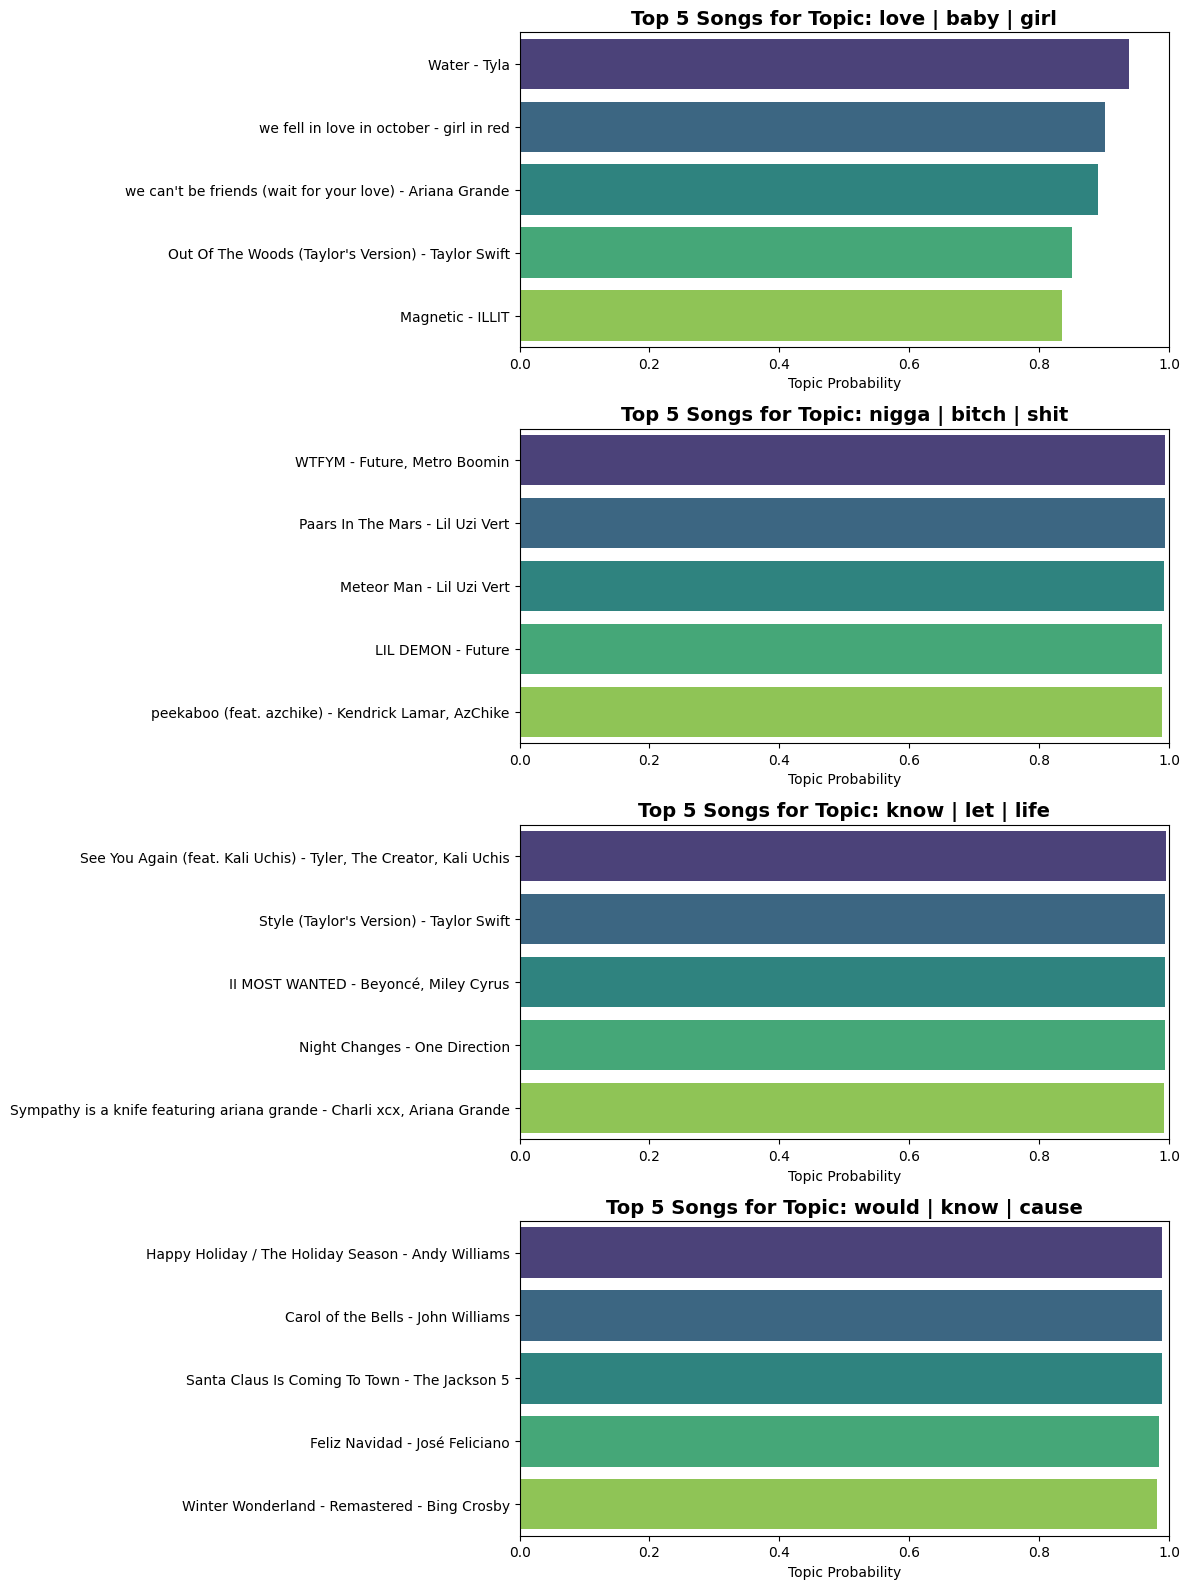

In [155]:
# Step 8 - Top Songs per Topic Bar Charts
fig, axes = plt.subplots(K, 1, figsize=(12, 4 * K), sharex=False)
plt.subplots_adjust(hspace=0.6)

for i, label in topic_labels.items():
    # Get top 5 songs for topic i with highest probability
    top_songs = df.sort_values(by=label, ascending=False).head(5)
    
    # Combine song name and artist for better context in plots
    song_names = top_songs["name"] + " - " + top_songs["artists"]
    
    ax = axes[i]
    sns.barplot(x=top_songs[label], y=song_names, ax=ax, palette="viridis")
    
    ax.set_title(f"Top 5 Songs for Topic: {label}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Topic Probability")
    ax.set_ylabel("")
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

#### Topics vs. Sentiment & Audio Features


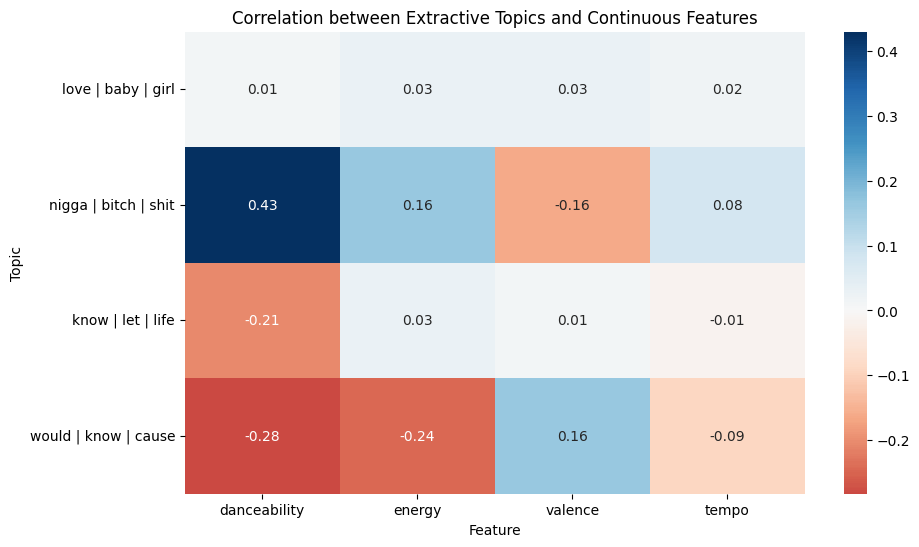

In [156]:
# 9. Correlation Matrix: Labeled Topics vs Audio/Sentiment Features
features_to_correlate = ['danceability', 'energy', 'valence', 'tempo']
corr_df = df[topic_cols + features_to_correlate].corr()
topic_feature_corr = corr_df.loc[topic_cols, features_to_correlate]

plt.figure(figsize=(10, 6))
sns.heatmap(topic_feature_corr, annot=True, cmap='RdBu', center=0, fmt=".2f")
plt.title("Correlation between Extractive Topics and Continuous Features")
plt.ylabel("Topic")
plt.xlabel("Feature")
plt.show()

Finally, we overwrite `lyrics_with_topics.pkl` to safely store the finalized Gensim topics mappings.

In [157]:
_output_path = PROCESSED / "lyrics_with_topics.pkl"

if not FORCE_RECOMPUTE and _output_path.exists():
    df = pd.read_pickle(_output_path)
    print("Loaded from cache:", _output_path)
else:
    # Step 10 — Save the enriched DataFrame
    df.to_pickle(PROCESSED / "lyrics_with_topics.pkl")
    df.to_csv(PROCESSED / "lyrics_with_topics.csv", index=False)
    print("Saved to:", PROCESSED)

Loaded from cache: /Users/felipe/Documents/BSE/Term-2/Text-mining/Final_project/data/processed/lyrics_with_topics.pkl
